# **Generative AI for Computer Vision**: HW1 - Image Classification using CNNs

**CSCE 689 — Fall 2026 (AI4CV)**

In this assignment, you will practice training a CNN from scratch on Tiny-ImageNet, which is a smaller version of ImageNet with 200 classes. Each class contains 500 images in the training set and 50 images in the testing set. The goals of this assignment are as follows:

- Understand the data-driven Image Classification pipeline (train/predict stages).
- Understand the train/val/test splits and the use of validation data for hyperparameter tuning.
- Learn how to finetune the pretrained model on the downstream task.

## Part 1: Training a CNN from scratch on Tiny ImageNet
In this part, you will train a CNN model from scratch, and evaluate your model on the given test set.
To finish this part, you will have to:
1. The data is split into train/val/test, the validation data is randomly selected from the training set, and the testing set is fixed. It is recommeded to do data augmentations, such as slight rotation. Please visit this website for more details: https://pytorch.org/vision/main/transforms.html
2. Create a customized CNN model at your own, any techniques, such as dropout, normalizations, are all welcomed!
3. Plot the training accuracy curve, report the testing accuracy and plot the confusion matrix.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch import Tensor
from typing import Type

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import pdb

import kagglehub

/tmp/ai4cv_hw1_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Download the Tiny ImageNet dataset from Kaggle
Please DO NOT modify this cell.

In [3]:
# Download tiny imagenet
base_dir = kagglehub.dataset_download("huchanwei123/cvrp-tinyimagenet")
print("Path to dataset files:", base_dir)
train_dir = os.path.join(base_dir, 'tiny-imagenet/train')
test_dir = os.path.join(base_dir, 'tiny-imagenet/test')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Path to dataset files: /tmp/ai4cv_kagglehub/datasets/huchanwei123/cvrp-tinyimagenet/versions/1


### Step 2: Create the data loader, and split it to train/val
1. The original folder structure is: \
   ├── train \
│   ├── labels (such as n01443537) \
│   │   ├── images \
│   │   │   ├── n01443537_0.JPEG \
│   │   │   ├── n01443537_1.JPEG \
│   │   │   ├── ... \
   It is highly recommended to use ```dataset.ImageFolder``` to load the data!
2. To check how to transform your data, check here: https://pytorch.org/vision/main/transforms.html
3. Later when you train the model, you might need to tune hyperparameters. For example, you may not want the fixed learning rate.


In [4]:
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder

# Parameters
img_size = 64

# Hyper-parameters for the training (NOTE: you can tune it!)
learning_rate = 3e-4
batch_size = 32
num_epochs = 100
num_classes = 200

mixup_alpha = 0.2
cutmix_alpha = 1.0
mix_probability = 0.8
cutmix_probability = 0.5
early_stopping_patience = 5
early_stopping_min_delta = 0.001

######################################### Data Loaders ##########################################
# For example, you might want to resize the image first so your model can take any input size.
# >   train_transforms = transforms.Compose([
#          transforms.Resize((img_size, img_size)),
#          transforms.ToTensor(),
#     ])
#################################################################################################
#                                         Your code here                                        #
#################################################################################################

normalize = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomCrop(img_size, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    normalize,
])

train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(train_dir, transform=val_transforms)

### Define the split ratio (e.g., 80% train, 20% validation)
# Your code
train_ratio = 0.8
val_ratio = 0.2


### Split the dataset, ex: using random_split 
# Your code
train_size = int(train_ratio * len(train_dataset))
val_size = len(train_dataset) - train_size
train_split, val_split = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_set = train_split
val_set = Subset(val_dataset, val_split.indices)

### Create data loaders with Pytorch DataLoader
# Your code
train_loader = DataLoader(train_set, batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size, shuffle=False)

### Step 3: Create your own CNN!
More details can be found here: https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch

In [5]:
### Define the custom CNN model
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)


class yourCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        blocks = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            blocks.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.classifier(x)

### Step 4: We are now ready to train the CNN model!
1. Define your model with your CNN class!
2. Define the loss function (```CrossEntropyLoss()```?) and the optimizer. More details can be found here: https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

In [6]:
### Define the model
model = yourCNN(num_classes=num_classes).to(device)

### Define the Loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4,
)

### Step 5: Implement your training procedure!
#### For training:
1. Iterate through each batch in the train dataloader
2. Reset the optimizer
3. Calculate the loss
4. Do backpropagation!
5. Keep track of the loss and accuracy when finishing this epoch

#### For evaluating:
Similar to the training process, but DON'T train the model! Only prediction!

**NOTE**: It is to modify the in/out arguments of ```train_model``` function

In [7]:
def mix_training_batch(
    inputs,
    labels,
    mixup_alpha=0.2,
    cutmix_alpha=1.0,
    mix_probability=0.8,
    cutmix_probability=0.5,
):
    if not 0.0 <= mix_probability <= 1.0:
        raise ValueError("mix_probability must be between 0 and 1")
    if not 0.0 <= cutmix_probability <= 1.0:
        raise ValueError("cutmix_probability must be between 0 and 1")
    if mixup_alpha <= 0 or cutmix_alpha <= 0:
        raise ValueError("Mixup and CutMix alpha values must be positive")

    if inputs.size(0) < 2 or np.random.random() >= mix_probability:
        return inputs, labels, labels, 1.0

    permutation = torch.randperm(inputs.size(0), device=inputs.device)
    labels_b = labels[permutation]
    use_cutmix = np.random.random() < cutmix_probability
    alpha = cutmix_alpha if use_cutmix else mixup_alpha
    lam = float(np.random.beta(alpha, alpha))

    if use_cutmix:
        height, width = inputs.shape[-2:]
        cut_ratio = np.sqrt(1.0 - lam)
        cut_height = int(height * cut_ratio)
        cut_width = int(width * cut_ratio)
        center_y = int(np.random.randint(height))
        center_x = int(np.random.randint(width))
        y1 = max(center_y - cut_height // 2, 0)
        y2 = min(center_y + (cut_height + 1) // 2, height)
        x1 = max(center_x - cut_width // 2, 0)
        x2 = min(center_x + (cut_width + 1) // 2, width)

        mixed_inputs = inputs.clone()
        mixed_inputs[:, :, y1:y2, x1:x2] = inputs[permutation, :, y1:y2, x1:x2]
        lam = 1.0 - ((y2 - y1) * (x2 - x1)) / float(height * width)
    else:
        mixed_inputs = lam * inputs + (1.0 - lam) * inputs[permutation]

    return mixed_inputs, labels, labels_b, lam


def mixed_target_loss(criterion, outputs, labels_a, labels_b, lam):
    return lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)


### Training function
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    checkpoint_path=None,
    resume=False,
    scheduler=None,
    best_model_path=None,
    mixup_alpha=0.2,
    cutmix_alpha=1.0,
    mix_probability=0.8,
    cutmix_probability=0.5,
    early_stopping_patience=5,
    early_stopping_min_delta=0.001,
):
    if early_stopping_patience is not None and (
        not isinstance(early_stopping_patience, int) or early_stopping_patience < 1
    ):
        raise ValueError("early_stopping_patience must be a positive integer or None")
    if early_stopping_min_delta < 0:
        raise ValueError("early_stopping_min_delta must be non-negative")

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    augmentation_config = {
        "mixup_alpha": mixup_alpha,
        "cutmix_alpha": cutmix_alpha,
        "mix_probability": mix_probability,
        "cutmix_probability": cutmix_probability,
    }
    start_epoch = 0
    best_val_accuracy = float("-inf")
    early_stopping_best_accuracy = float("-inf")
    epochs_without_improvement = 0

    if resume:
        if not checkpoint_path:
            raise ValueError("checkpoint_path is required when resume=True")
        if os.path.isfile(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=device)
            if checkpoint.get("augmentation_config") != augmentation_config:
                raise ValueError(
                    "Checkpoint augmentation settings do not match this run. "
                    "Use a new checkpoint path and resume=False for a new experiment."
                )
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
                scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            start_epoch = checkpoint["epoch"]
            train_losses = checkpoint["train_losses"]
            val_losses = checkpoint["val_losses"]
            train_accuracies = checkpoint["train_accuracies"]
            val_accuracies = checkpoint["val_accuracies"]
            early_stopping_best_accuracy = max(val_accuracies, default=float("-inf"))
            early_stopping_state = checkpoint.get("early_stopping_state", {})
            if (
                early_stopping_state.get("patience") == early_stopping_patience
                and early_stopping_state.get("min_delta") == early_stopping_min_delta
            ):
                early_stopping_best_accuracy = early_stopping_state["best_accuracy"]
                epochs_without_improvement = early_stopping_state["epochs_without_improvement"]
            print(f"Resuming from epoch {start_epoch}")

            if best_model_path and os.path.isfile(best_model_path):
                best_checkpoint = torch.load(best_model_path, map_location=device)
                best_val_accuracy = best_checkpoint["val_accuracy"]
            elif best_model_path and val_accuracies:
                best_val_accuracy = val_accuracies[-1]
                best_model_dir = os.path.dirname(best_model_path)
                if best_model_dir:
                    os.makedirs(best_model_dir, exist_ok=True)
                torch.save(
                    {
                        "epoch": start_epoch,
                        "model_state_dict": model.state_dict(),
                        "val_accuracy": best_val_accuracy,
                    },
                    best_model_path,
                )
        else:
            print("No checkpoint found; starting from scratch")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_loss_total = 0.0
        train_correct = 0
        train_total = 0

        for batch_index, (inputs, labels) in enumerate(train_loader, start=1):
            inputs = inputs.to(device)
            labels = labels.to(device)

            inputs, labels_a, labels_b, lam = mix_training_batch(
                inputs, labels, **augmentation_config
            )
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = mixed_target_loss(criterion, outputs, labels_a, labels_b, lam)
            loss.backward()
            optimizer.step()

            batch_count = labels.size(0)
            train_loss_total += loss.item() * batch_count
            predictions = outputs.argmax(dim=1)
            train_correct += (
                lam * (predictions == labels_a).sum().item()
                + (1.0 - lam) * (predictions == labels_b).sum().item()
            )
            train_total += batch_count

            if batch_index % 500 == 0 or batch_index == len(train_loader):
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}] "
                    f"Batch [{batch_index}/{len(train_loader)}] "
                    f"Train Loss: {train_loss_total / train_total:.4f}, "
                    f"Train Mixed Accuracy: {train_correct / train_total:.4f}",
                    flush=True,
                )

        train_losses.append(train_loss_total / train_total)
        train_accuracies.append(train_correct / train_total)

        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                batch_count = labels.size(0)
                val_loss_total += loss.item() * batch_count
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += batch_count

        val_losses.append(val_loss_total / val_total)
        val_accuracies.append(val_correct / val_total)

        if scheduler is not None:
            scheduler.step(val_losses[-1])

        if best_model_path and val_accuracies[-1] > best_val_accuracy:
            best_val_accuracy = val_accuracies[-1]
            best_model_dir = os.path.dirname(best_model_path)
            if best_model_dir:
                os.makedirs(best_model_dir, exist_ok=True)
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "val_accuracy": best_val_accuracy,
                },
                best_model_path,
            )

        if (
            val_accuracies[-1] > early_stopping_best_accuracy
            and val_accuracies[-1] - early_stopping_best_accuracy >= early_stopping_min_delta
        ):
            early_stopping_best_accuracy = val_accuracies[-1]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        should_stop = (
            early_stopping_patience is not None
            and epochs_without_improvement >= early_stopping_patience
        )

        if checkpoint_path and (
            (epoch + 1) % 5 == 0 or epoch + 1 == num_epochs or should_stop
        ):
            checkpoint_dir = os.path.dirname(checkpoint_path)
            if checkpoint_dir:
                os.makedirs(checkpoint_dir, exist_ok=True)
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "augmentation_config": augmentation_config,
                    "early_stopping_state": {
                        "patience": early_stopping_patience,
                        "min_delta": early_stopping_min_delta,
                        "best_accuracy": early_stopping_best_accuracy,
                        "epochs_without_improvement": epochs_without_improvement,
                    },
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "train_accuracies": train_accuracies,
                    "val_accuracies": val_accuracies,
                },
                checkpoint_path,
            )

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_losses[-1]:.4f}, "
            f"Train Mixed Accuracy: {train_accuracies[-1]:.4f}, "
            f"Val Loss: {val_losses[-1]:.4f}, "
            f"Val Accuracy: {val_accuracies[-1]:.4f}, "
            f"LR: {optimizer.param_groups[0]['lr']:.6g}"
        )

        if should_stop:
            print(
                f"Early stopping at epoch {epoch + 1}: validation accuracy did not "
                f"improve by at least {early_stopping_min_delta:.4f} for "
                f"{early_stopping_patience} consecutive epochs."
            )
            break

    return train_losses, val_losses, train_accuracies, val_accuracies, model


### Step 6: Start training the model!
Actually nothing to do in this cell...

In [31]:
import platform
print(platform.system())

Linux


In [32]:
print(device)
print(torch.cuda.is_available())

cuda
True


In [ ]:
### Train the residual CNN with label smoothing and keep the best validation model
checkpoint_path = 'cnn_resnet_wide_ls_mixup_cutmix_checkpoint.pth'
best_model_path = 'cnn_resnet_wide_ls_mixup_cutmix_best_weights.pth'
resume_checkpoint = False

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

train_losses, val_losses, train_accuracies, val_accuracies, model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path,
    resume=resume_checkpoint,
    scheduler=scheduler,
    best_model_path=best_model_path,
    mixup_alpha=mixup_alpha,
    cutmix_alpha=cutmix_alpha,
    mix_probability=mix_probability,
    cutmix_probability=cutmix_probability,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)

best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
print(f"Using best validation checkpoint from epoch {best_checkpoint['epoch']}")
torch.save(
    model.state_dict(),
    'CNN_resnet_wide_ls_mixup_cutmix_weights.pth',
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Mixed Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Epoch [1/100] Batch [500/2500] Train Loss: 5.2013, Train Mixed Accuracy: 0.0197
Epoch [1/100] Batch [1000/2500] Train Loss: 5.0856, Train Mixed Accuracy: 0.0279
Epoch [1/100] Batch [1500/2500] Train Loss: 5.0093, Train Mixed Accuracy: 0.0344
Epoch [1/100] Batch [2000/2500] Train Loss: 4.9450, Train Mixed Accuracy: 0.0414
Epoch [1/100] Batch [2500/2500] Train Loss: 4.8861, Train Mixed Accuracy: 0.0491
Epoch [1/100] Train Loss: 4.8861, Train Mixed Accuracy: 0.0491, Val Loss: 4.3245, Val Accuracy: 0.1184, LR: 0.0003


### Step 7: Evaluate your model on testing set and plot the confusion matrix
In this part, you will learn to evaluate a trained model on testing set, and plot the confusion matrix.
Ideally, a great classification model would have non-zero values only along the diagonal, with zeros in all off-diagonal elements.

**HINTS**
1. Remember to perform the same transforms to your testing set as the validation set.
2. In ```get_predictions```, it is basically the same as you do evaluation.

Test Accuracy: 0.6067


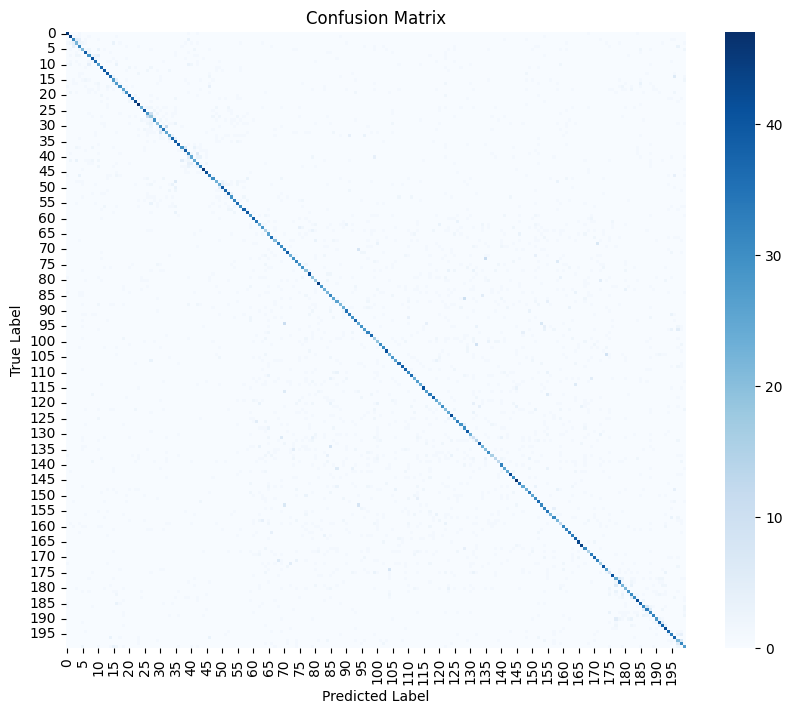

In [7]:
############################### Test Data Loader ##############################
###############################################################################
#                                 Your code here                              #
###############################################################################

test_dataset = ImageFolder(test_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

### If you don't want to train the model again, you can restore it!
# ==> model.load_state_dict(torch.load('/path/to/your/saved/model.pth'))

# Change model to evaluation phase
model.load_state_dict(torch.load(
    'cnn_resnet_wide_ls_mixup_cutmix_best_weights.pth',
    map_location=device, weights_only=True,
)["model_state_dict"])
model.eval()

# Function to get predictions and true labels
def get_predictions(model, dataloader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    #############################################################
    #                      Your code here                       #
    #############################################################
    return np.array(all_predictions), np.array(all_labels)


### Get predictions and true labels
predictions, true_labels = get_predictions(model, test_loader)

################# Compute confusion matrix ##################
#############################################################
# cm = ?                                                    #
#############################################################
cm = confusion_matrix(true_labels, predictions, labels=np.arange(num_classes))

### Calculate accuracy
accuracy = (predictions == true_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Questions
1. Did you observe overfitting? If yes, how did you address it?
2. The original dataset is well-balanced, that is, each class has the same number of training examples. However, this rarely happens in the real situation because some classes may dominate the training set. For example, in autonomous driving application, most training data are vehicles moving forward, while moving backwards take a small amount. This is called longtailed dataset. You will have to train the same CNN model on tiny-imagenet dataset with longtailed distribution.
   
   ```base_dir = kagglehub.dataset_download("huchanwei123/cvrp-tinyimagenet-lt")``` \
   ```train_dir = os.path.join(base_dir, 'tiny-imagenet-lt/train')``` \
   ```test_dir = os.path.join(base_dir, 'tiny-imagenet-lt/test')```

   Please plot out the trainig data distribuion (x-axis: class ID, y-axis: number of images), and analyze the performance compared to original dataset.
3. With your results trained on longtailed tiny-imagenet, you might observe the lower testing accuracy. Please try to improve the algorithm by performing a more **aggresive data augmentation** or **frequent re-sampling on tail classes**. (Note: Just try your best!)

Long-tailed split: 34681 train, 8674 validation, 10000 test; 200 classes
Class counts: min=68, max=500, imbalance ratio=7.35


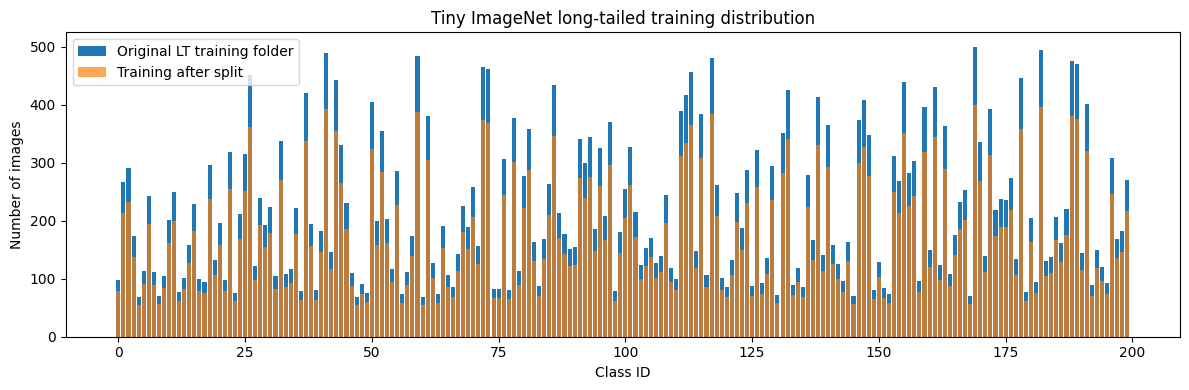

In [ ]:
from torch.utils.data import WeightedRandomSampler
import json
import random

lt_seed = 42
lt_base_dir = kagglehub.dataset_download("huchanwei123/cvrp-tinyimagenet-lt")
lt_train_dir = os.path.join(lt_base_dir, "tiny-imagenet-lt/train")
lt_test_dir = os.path.join(lt_base_dir, "tiny-imagenet-lt/test")
lt_train_dataset = ImageFolder(lt_train_dir, transform=train_transforms)
lt_val_dataset = ImageFolder(lt_train_dir, transform=val_transforms)
lt_test_dataset = ImageFolder(lt_test_dir, transform=val_transforms)
assert lt_train_dataset.class_to_idx == lt_test_dataset.class_to_idx
assert lt_train_dataset.class_to_idx == train_dataset.class_to_idx
lt_labels = np.asarray(lt_train_dataset.targets)
lt_class_counts = np.bincount(lt_labels, minlength=num_classes)
lt_rng = np.random.default_rng(lt_seed)
lt_train_indices, lt_val_indices = [], []
for class_id in range(num_classes):
    indices = np.flatnonzero(lt_labels == class_id)
    lt_rng.shuffle(indices)
    n_val = max(1, min(len(indices) - 1, int(round(val_ratio * len(indices)))))
    lt_val_indices.extend(indices[:n_val].tolist())
    lt_train_indices.extend(indices[n_val:].tolist())
lt_train_set = Subset(lt_train_dataset, lt_train_indices)
lt_val_set = Subset(lt_val_dataset, lt_val_indices)
lt_train_counts = np.bincount(lt_labels[lt_train_indices], minlength=num_classes)
lt_loader_options = dict(batch_size=batch_size, num_workers=4,
                         pin_memory=(device.type == "cuda"))
lt_val_loader = DataLoader(lt_val_set, shuffle=False, **lt_loader_options)
lt_test_loader = DataLoader(lt_test_dataset, shuffle=False, **lt_loader_options)
print(f"Long-tailed split: {len(lt_train_set)} train, {len(lt_val_set)} validation, "
      f"{len(lt_test_dataset)} test; {num_classes} classes")
print(f"Class counts: min={lt_class_counts.min()}, max={lt_class_counts.max()}, "
      f"imbalance ratio={lt_class_counts.max() / lt_class_counts.min():.2f}")
plt.figure(figsize=(12, 4))
plt.bar(np.arange(num_classes), lt_class_counts, label="Original LT training folder")
plt.bar(np.arange(num_classes), lt_train_counts, alpha=0.7, label="Training after split")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.title("Tiny ImageNet long-tailed training distribution")
plt.legend()
plt.tight_layout()
plt.savefig("part1_lt_distribution.png", dpi=150)
plt.show()


START baseline: training epochs begin now.


Epoch [1/100] Batch [500/1084] Train Loss: 5.0397, Train Mixed Accuracy: 0.0357


Epoch [1/100] Batch [1000/1084] Train Loss: 4.9459, Train Mixed Accuracy: 0.0431


Epoch [1/100] Batch [1084/1084] Train Loss: 4.9306, Train Mixed Accuracy: 0.0450


Epoch [1/100] Train Loss: 4.9306, Train Mixed Accuracy: 0.0450, Val Loss: 4.6001, Val Accuracy: 0.0757, LR: 0.0003


...

Epoch [62/100] Batch [500/1084] Train Loss: 2.0385, Train Mixed Accuracy: 0.7705


Epoch [62/100] Batch [1000/1084] Train Loss: 2.1038, Train Mixed Accuracy: 0.7548


Epoch [62/100] Batch [1084/1084] Train Loss: 2.1033, Train Mixed Accuracy: 0.7551


Epoch [62/100] Train Loss: 2.1033, Train Mixed Accuracy: 0.7551, Val Loss: 2.6374, Val Accuracy: 0.5425, LR: 4.6875e-06
Early stopping at epoch 62: validation accuracy did not improve by at least 0.0010 for 5 consecutive epochs.


RESULT baseline: {"test_accuracy": 0.4732, "epochs_run": 62, "best_val_accuracy": 0.5442702328798709}


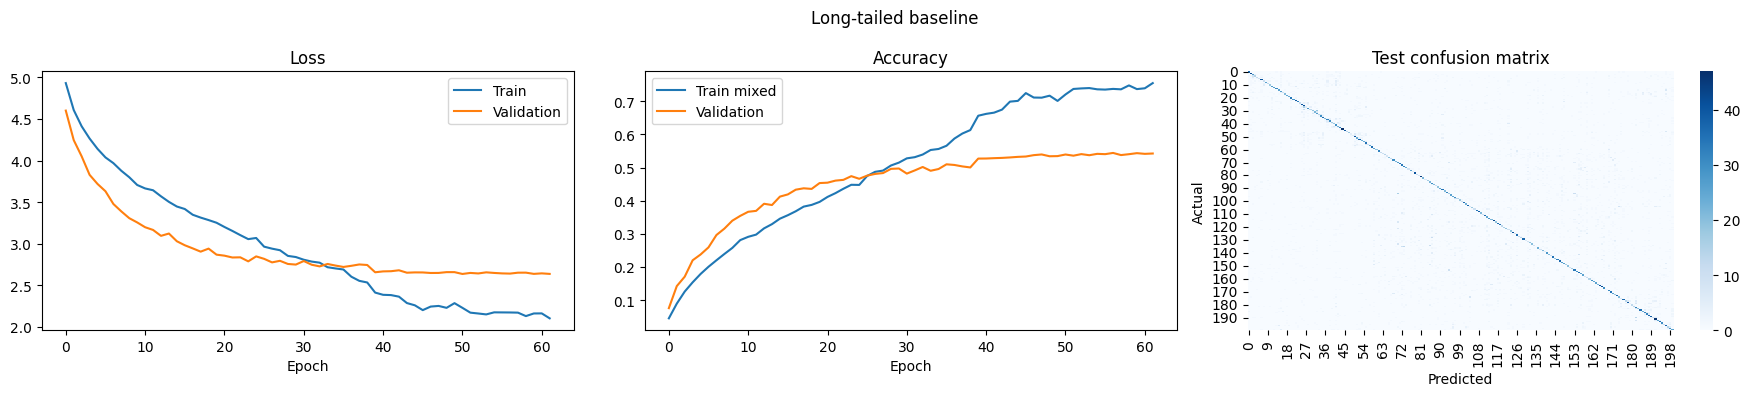

START tail_resampling: training epochs begin now.


Epoch [1/100] Batch [500/1084] Train Loss: 5.1844, Train Mixed Accuracy: 0.0215


Epoch [1/100] Batch [1000/1084] Train Loss: 5.0768, Train Mixed Accuracy: 0.0287


Epoch [1/100] Batch [1084/1084] Train Loss: 5.0615, Train Mixed Accuracy: 0.0299


Epoch [1/100] Train Loss: 5.0615, Train Mixed Accuracy: 0.0299, Val Loss: 4.7151, Val Accuracy: 0.0544, LR: 0.0003


...

Epoch [50/100] Batch [500/1084] Train Loss: 2.2725, Train Mixed Accuracy: 0.7039


Epoch [50/100] Batch [1000/1084] Train Loss: 2.3125, Train Mixed Accuracy: 0.6975


Epoch [50/100] Batch [1084/1084] Train Loss: 2.3140, Train Mixed Accuracy: 0.6970


Epoch [50/100] Train Loss: 2.3140, Train Mixed Accuracy: 0.6970, Val Loss: 2.7288, Val Accuracy: 0.5082, LR: 1.875e-05
Early stopping at epoch 50: validation accuracy did not improve by at least 0.0010 for 5 consecutive epochs.


RESULT tail_resampling: {"test_accuracy": 0.461, "epochs_run": 50, "best_val_accuracy": 0.5097994005072631}


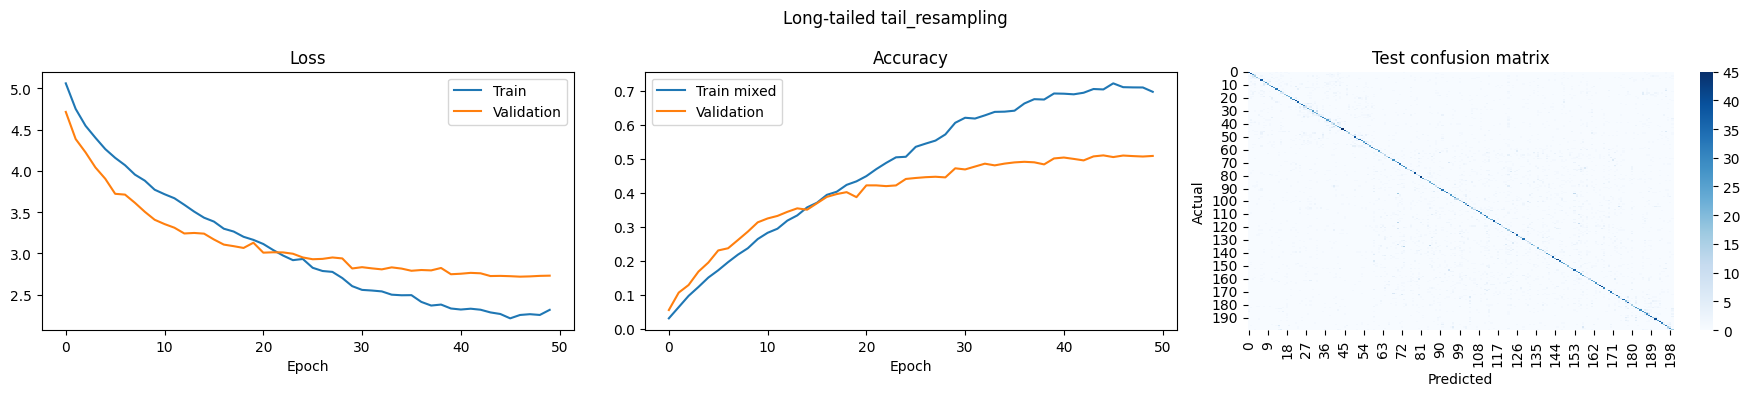

In [10]:
lt_results = {}
lt_histories = {}
lt_initial_state = None

def lt_reset_seed():
    random.seed(lt_seed)
    np.random.seed(lt_seed)
    torch.manual_seed(lt_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(lt_seed)

lt_reset_seed()
lt_initial_model = yourCNN(num_classes=num_classes)
lt_initial_state = {k: v.detach().clone() for k, v in lt_initial_model.state_dict().items()}
del lt_initial_model

def lt_evaluate_model(trained_model):
    predicted, actual = get_predictions(trained_model, lt_test_loader)
    matrix = confusion_matrix(actual, predicted, labels=np.arange(num_classes))
    result = {"test_accuracy": float((predicted == actual).mean())}
    return result, matrix

for lt_experiment in ("baseline", "tail_resampling"):
    lt_reset_seed()
    lt_model = yourCNN(num_classes=num_classes).to(device)
    lt_model.load_state_dict(lt_initial_state)
    generator = torch.Generator().manual_seed(lt_seed)
    if lt_experiment == "tail_resampling":
        sample_weights = 1.0 / lt_train_counts[lt_labels[lt_train_indices]]
        lt_sampler = WeightedRandomSampler(
            torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(lt_train_set), replacement=True, generator=generator)
        lt_train_loader = DataLoader(lt_train_set, sampler=lt_sampler, **lt_loader_options)
    else:
        lt_train_loader = DataLoader(lt_train_set, shuffle=True,
                                     generator=generator, **lt_loader_options)
    lt_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    lt_optimizer = optim.AdamW(lt_model.parameters(), lr=learning_rate, weight_decay=1e-4)
    lt_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        lt_optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
    lt_prefix = "part1_lt_" + lt_experiment
    print(f"START {lt_experiment}: training epochs begin now.", flush=True)
    lt_training = train_model(
        lt_model, lt_train_loader, lt_val_loader, lt_criterion, lt_optimizer,
        num_epochs=num_epochs, checkpoint_path=lt_prefix + "_checkpoint.pth",
        resume=False, scheduler=lt_scheduler,
        best_model_path=lt_prefix + "_best_weights.pth",
        mixup_alpha=mixup_alpha, cutmix_alpha=cutmix_alpha,
        mix_probability=mix_probability, cutmix_probability=cutmix_probability,
        early_stopping_patience=early_stopping_patience,
        early_stopping_min_delta=early_stopping_min_delta)
    lt_histories[lt_experiment] = {
        "train_loss": lt_training[0], "val_loss": lt_training[1],
        "train_mixed_accuracy": lt_training[2], "val_accuracy": lt_training[3]}
    lt_best = torch.load(lt_prefix + "_best_weights.pth", map_location=device)
    lt_model.load_state_dict(lt_best["model_state_dict"])
    lt_metrics, lt_cm = lt_evaluate_model(lt_model)
    lt_metrics.update(best_epoch=int(lt_best["epoch"]),
                      epochs_run=len(lt_training[0]),
                      best_val_accuracy=float(lt_best["val_accuracy"]))
    lt_results[lt_experiment] = lt_metrics
    np.save(lt_prefix + "_confusion_matrix.npy", lt_cm)
    torch.save(lt_model.state_dict(), lt_prefix + "_weights.pth")
    with open("part1_lt_results.json", "w") as lt_file:
        json.dump({"seed": lt_seed, "split": "stratified 80/20",
                   "training_class_counts": lt_train_counts.tolist(),
                   "results": lt_results, "histories": lt_histories}, lt_file, indent=2)
    result_summary = {key: value for key, value in lt_metrics.items() if key != "best_epoch"}
    print(f"RESULT {lt_experiment}: {json.dumps(result_summary)}", flush=True)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(lt_training[0], label="Train")
    axes[0].plot(lt_training[1], label="Validation")
    axes[0].set(title="Loss", xlabel="Epoch")
    axes[1].plot(lt_training[2], label="Train mixed")
    axes[1].plot(lt_training[3], label="Validation")
    axes[1].set(title="Accuracy", xlabel="Epoch")
    sns.heatmap(lt_cm, cmap="Blues", ax=axes[2])
    axes[2].set(title="Test confusion matrix", xlabel="Predicted", ylabel="Actual")
    axes[0].legend()
    axes[1].legend()
    fig.suptitle("Long-tailed " + lt_experiment)
    fig.tight_layout()
    fig.savefig(lt_prefix + "_training_and_confusion.png", dpi=150)
    plt.show()
    del lt_model, lt_optimizer, lt_scheduler, lt_training
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [11]:
balanced_reference_model = yourCNN(num_classes=num_classes).to(device)
balanced_checkpoint = torch.load(
    "cnn_resnet_wide_ls_mixup_cutmix_best_weights.pth", map_location=device)
balanced_reference_model.load_state_dict(balanced_checkpoint["model_state_dict"])
balanced_predictions, balanced_labels = get_predictions(balanced_reference_model, test_loader)
balanced_test_accuracy = float((balanced_predictions == balanced_labels).mean())
print(f"Balanced historical test accuracy: {balanced_test_accuracy:.2%}")
print(f"{'Experiment':38} {'Epochs':>8} {'Val':>10} {'Test':>10}")
for experiment, metrics in lt_results.items():
    epochs_run = metrics.get("epochs_run", metrics.get("continuation_epochs_run"))
    print(f"{experiment:38} {epochs_run:8d} "
          f"{metrics['best_val_accuracy']:10.2%} {metrics['test_accuracy']:10.2%}")
baseline = lt_results["baseline"]
resampled = lt_results["tail_resampling"]
print(f"LT baseline minus balanced: "
      f"{100 * (baseline['test_accuracy'] - balanced_test_accuracy):+.2f} percentage points")
print(f"Resampling changes overall test accuracy by "
      f"{100 * (resampled['test_accuracy'] - baseline['test_accuracy']):+.2f} percentage points.")
print("The balanced historical run used a random 80/20 split; LT uses stratified 80/20 "
      "so every class is represented. Dataset size and split differ, so this comparison "
      "measures the complete dataset change rather than isolating imbalance alone.")
del balanced_reference_model


Balanced historical test accuracy: 60.67%
Experiment                               Epochs        Val       Test
baseline                                     62     54.43%     47.32%
tail_resampling                              50     50.98%     46.10%
LT baseline minus balanced: -13.35 percentage points
Resampling changes overall test accuracy by -1.22 percentage points.
The balanced historical run used a random 80/20 split; LT uses stratified 80/20 so every class is represented. Dataset size and split differ, so this comparison measures the complete dataset change rather than isolating imbalance alone.


In [8]:
lt_aggressive_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), value=0.0),
])
lt_aggressive_dataset = ImageFolder(lt_train_dir, transform=lt_aggressive_transforms)
assert lt_aggressive_dataset.class_to_idx == lt_train_dataset.class_to_idx
lt_aggressive_train_set = Subset(lt_aggressive_dataset, lt_train_indices)
random.seed(lt_seed)
np.random.seed(lt_seed)
torch.manual_seed(lt_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(lt_seed)
lt_aggressive_model = yourCNN(num_classes=num_classes).to(device)
lt_aggressive_generator = torch.Generator().manual_seed(lt_seed)
lt_aggressive_sample_weights = 1.0 / np.sqrt(lt_train_counts[lt_labels[lt_train_indices]])
lt_aggressive_sampler = WeightedRandomSampler(
    torch.as_tensor(lt_aggressive_sample_weights, dtype=torch.double),
    num_samples=len(lt_train_indices), replacement=True, generator=lt_aggressive_generator)
lt_aggressive_train_loader = DataLoader(
    lt_aggressive_train_set, sampler=lt_aggressive_sampler, **lt_loader_options)
lt_aggressive_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
lt_aggressive_optimizer = optim.AdamW(
    lt_aggressive_model.parameters(), lr=learning_rate, weight_decay=1e-4)
lt_aggressive_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    lt_aggressive_optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
lt_aggressive_prefix = "part1_lt_aggressive_resampling"
print("Training all layers of the same CNN from seeded scratch initialization.")
print("Training augmentation:", lt_aggressive_transforms)
print("Tail sampling weight: inverse square root of class frequency; "
      "same number of training samples per epoch.")
print(f"Same split: {len(lt_aggressive_train_set)} training, "
      f"{len(lt_val_set)} validation, {len(lt_test_dataset)} test images.")


Training all layers of the same CNN from seeded scratch initialization.
Training augmentation: Compose(
    RandomResizedCrop(size=(64, 64), scale=(0.6, 1.0), ratio=(0.8, 1.25), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.08, 0.08))
    RandAugment(num_ops=2, magnitude=7, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0, inplace=False)
)
Tail sampling weight: inverse square root of class frequency; same number of training samples per epoch.
Same split: 34681 training, 8674 validation, 10000 test images.


START aggressive augmentation + frequent tail resampling: epochs begin now.


Epoch [1/100] Batch [500/1084] Train Loss: 5.2429, Train Mixed Accuracy: 0.0159


Epoch [1/100] Batch [1000/1084] Train Loss: 5.1798, Train Mixed Accuracy: 0.0199


Epoch [1/100] Batch [1084/1084] Train Loss: 5.1694, Train Mixed Accuracy: 0.0208


Epoch [1/100] Train Loss: 5.1694, Train Mixed Accuracy: 0.0208, Val Loss: 4.8844, Val Accuracy: 0.0551, LR: 0.0003


...

Epoch [54/100] Train Loss: 2.9502, Train Mixed Accuracy: 0.4899, Val Loss: 2.6926, Val Accuracy: 0.5035, LR: 1.875e-05


Epoch [55/100] Batch [500/1084] Train Loss: 2.9049, Train Mixed Accuracy: 0.5058


Epoch [55/100] Batch [1000/1084] Train Loss: 2.9673, Train Mixed Accuracy: 0.4890


Epoch [55/100] Batch [1084/1084] Train Loss: 2.9665, Train Mixed Accuracy: 0.4890


Epoch [55/100] Train Loss: 2.9665, Train Mixed Accuracy: 0.4890, Val Loss: 2.7091, Val Accuracy: 0.5005, LR: 1.875e-05
Early stopping at epoch 55: validation accuracy did not improve by at least 0.0010 for 5 consecutive epochs.


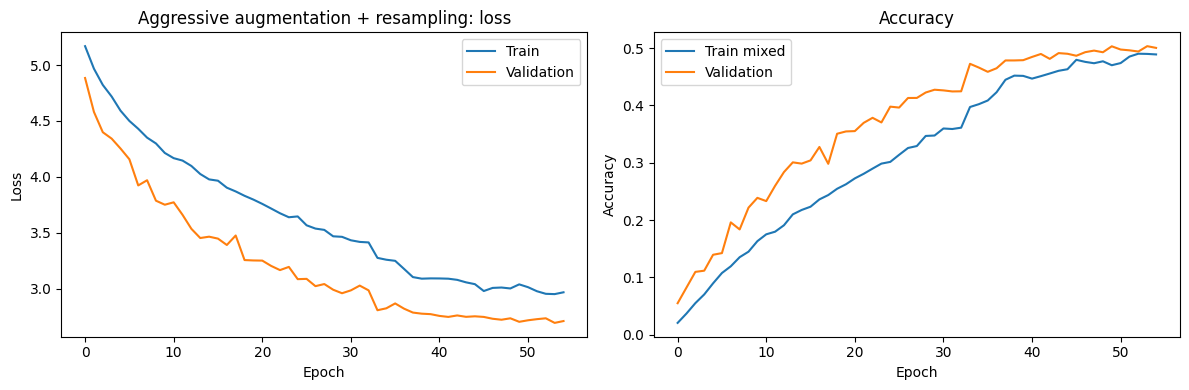

Selected best validation checkpoint: epoch 54, validation accuracy 50.35%


In [9]:
print("START aggressive augmentation + frequent tail resampling: epochs begin now.", flush=True)
lt_aggressive_training = train_model(
    lt_aggressive_model, lt_aggressive_train_loader, lt_val_loader,
    lt_aggressive_criterion, lt_aggressive_optimizer,
    num_epochs=num_epochs, checkpoint_path=lt_aggressive_prefix + "_checkpoint.pth",
    resume=False, scheduler=lt_aggressive_scheduler,
    best_model_path=lt_aggressive_prefix + "_best_weights.pth",
    mixup_alpha=mixup_alpha, cutmix_alpha=cutmix_alpha,
    mix_probability=mix_probability, cutmix_probability=cutmix_probability,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta)
lt_aggressive_best = torch.load(
    lt_aggressive_prefix + "_best_weights.pth", map_location=device)
lt_aggressive_model.load_state_dict(lt_aggressive_best["model_state_dict"])
torch.save(lt_aggressive_model.state_dict(), lt_aggressive_prefix + "_weights.pth")
lt_aggressive_history = {
    "train_loss": lt_aggressive_training[0], "val_loss": lt_aggressive_training[1],
    "train_mixed_accuracy": lt_aggressive_training[2], "val_accuracy": lt_aggressive_training[3]}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lt_aggressive_training[0], label="Train")
axes[0].plot(lt_aggressive_training[1], label="Validation")
axes[0].set(title="Aggressive augmentation + resampling: loss", xlabel="Epoch", ylabel="Loss")
axes[1].plot(lt_aggressive_training[2], label="Train mixed")
axes[1].plot(lt_aggressive_training[3], label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.legend()
fig.tight_layout()
fig.savefig(lt_aggressive_prefix + "_training.png", dpi=150)
plt.show()
print(f"Selected best validation checkpoint: epoch {lt_aggressive_best['epoch']}, "
      f"validation accuracy {lt_aggressive_best['val_accuracy']:.2%}")


Experiment                                    Epochs        Val       Test
baseline                                          62     54.43%     47.32%
tail_resampling                                   50     50.98%     46.10%
aggressive_augmentation_resampling                55     50.35%     45.22%


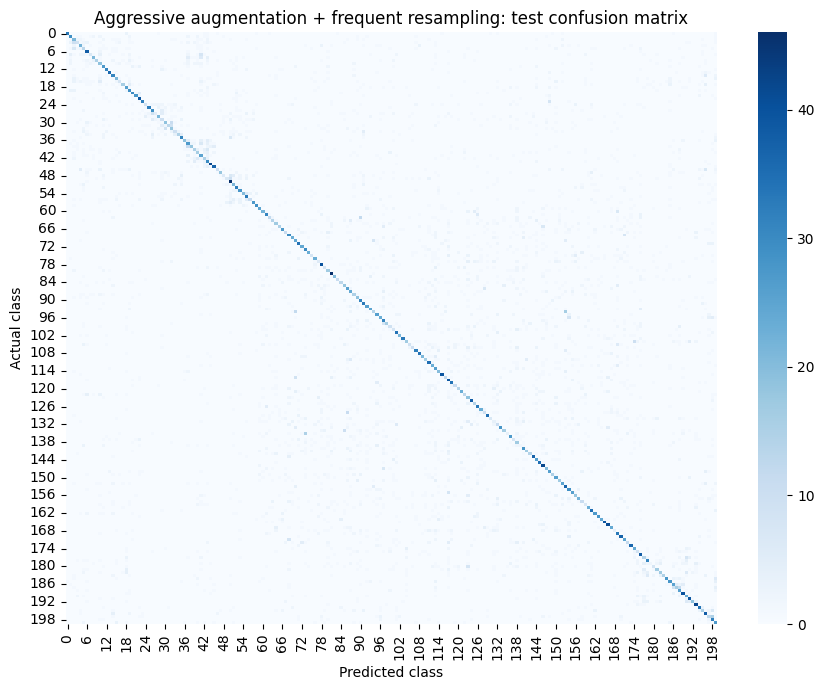

In [10]:
lt_aggressive_predictions, lt_aggressive_actual = get_predictions(
    lt_aggressive_model, lt_test_loader)
lt_aggressive_cm = confusion_matrix(
    lt_aggressive_actual, lt_aggressive_predictions, labels=np.arange(num_classes))
lt_aggressive_metrics = {
    "test_accuracy": float((lt_aggressive_predictions == lt_aggressive_actual).mean()),
    "best_epoch": int(lt_aggressive_best["epoch"]),
    "epochs_run": len(lt_aggressive_training[0]),
    "best_val_accuracy": float(lt_aggressive_best["val_accuracy"])}
with open(lt_aggressive_prefix + "_results.json", "w") as results_file:
    json.dump({"seed": lt_seed,
               "method": "same CNN from scratch; aggressive augmentation and inverse-sqrt tail resampling",
               "selection": "same validation accuracy early stopping as previous LT experiments",
               "training_class_counts": lt_train_counts.tolist(),
               "metrics": lt_aggressive_metrics, "history": lt_aggressive_history}, results_file, indent=2)
np.save(lt_aggressive_prefix + "_confusion_matrix.npy", lt_aggressive_cm)
with open("part1_lt_results.json") as prior_results_file:
    lt_assignment_results = json.load(prior_results_file)["results"]
lt_assignment_results["aggressive_augmentation_resampling"] = lt_aggressive_metrics
print(f"{'Experiment':43} {'Epochs':>8} {'Val':>10} {'Test':>10}")
for experiment, metrics in lt_assignment_results.items():
    epochs_run = metrics.get("epochs_run", metrics.get("continuation_epochs_run"))
    print(f"{experiment:43} {epochs_run:8d} "
          f"{metrics['best_val_accuracy']:10.2%} {metrics['test_accuracy']:10.2%}")
plt.figure(figsize=(9, 7))
sns.heatmap(lt_aggressive_cm, cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Aggressive augmentation + frequent resampling: test confusion matrix")
plt.tight_layout()
plt.savefig(lt_aggressive_prefix + "_confusion.png", dpi=150)
plt.show()


In [1]:
import json
from pathlib import Path

with open("part1_lt_aggressive_resampling_results.json") as final_results_file:
    final_lt_results = json.load(final_results_file)
final_lt_model_path = Path("part1_lt_aggressive_resampling_weights.pth")
if not final_lt_model_path.is_file():
    raise FileNotFoundError(final_lt_model_path)
final_lt_metrics = final_lt_results["metrics"]
print("Final long-tailed method: aggressive data augmentation + frequent tail resampling")
print("Architecture: same CNN, trained from scratch on long-tailed Tiny ImageNet")
print("Resampling: inverse-square-root class frequency, with replacement")
print(f"Best epoch: {final_lt_metrics['best_epoch']}; epochs completed: {final_lt_metrics['epochs_run']}")
print(f"Validation accuracy: {final_lt_metrics['best_val_accuracy']:.2%}")
print(f"Test accuracy: {final_lt_metrics['test_accuracy']:.2%}")
print(f"Final model weights: {final_lt_model_path}")


Final long-tailed method: aggressive data augmentation + frequent tail resampling
Architecture: same CNN, trained from scratch on long-tailed Tiny ImageNet
Resampling: inverse-square-root class frequency, with replacement
Best epoch: 54; epochs completed: 55
Validation accuracy: 50.35%
Test accuracy: 45.22%
Final model weights: part1_lt_aggressive_resampling_weights.pth
